## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [1]:
# TODO: import pandas, numpy, matplotlib.pyplot, and seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# TODO: load shopping_trends.csv with pd.read_csv(), then show the first 5 rows
df = pd.read_csv('shopping_trends.csv')
print(df.head())

   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

  Payment Method  Shipping Type Discount Applied Promo C

In [3]:
# TODO: check the dataset size with df.shape
df.shape


(3900, 19)

In [7]:
# TODO: drop the Customer ID column
df = df.drop(columns=['Customer ID'])


KeyError: "['Customer ID'] not found in axis"

In [9]:
df.shape

(3900, 18)

### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [11]:
# TODO: check columns, dtypes, and non-null counts with df.info()
df.info()
df.columns
df.dtypes
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       3900 non-null   int64  
 1   Gender                    3900 non-null   object 
 2   Item Purchased            3900 non-null   object 
 3   Category                  3900 non-null   object 
 4   Purchase Amount (USD)     3900 non-null   int64  
 5   Location                  3900 non-null   object 
 6   Size                      3900 non-null   object 
 7   Color                     3900 non-null   object 
 8   Season                    3900 non-null   object 
 9   Review Rating             3900 non-null   float64
 10  Subscription Status       3900 non-null   object 
 11  Payment Method            3900 non-null   object 
 12  Shipping Type             3900 non-null   object 
 13  Discount Applied          3900 non-null   object 
 14  Promo Co

Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [12]:
# TODO: check missing values with df.isnull().sum()
df.isnull().sum()

Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [13]:
# TODO: check duplicate rows with df.duplicated().sum()
df.duplicated().sum()

np.int64(0)

In [14]:
# TODO: univariate — describe numeric columns
df.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


In [16]:
# TODO: split the data into male_df and female_df using df[df['Gender']==...]
male_df = df[df['Gender'] == 'Male']
female_df = df[df['Gender'] == 'Female']
df

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


## **EDA**

### **Item Purchased**

In [20]:
# TODO: count top items with value_counts().reset_index() for male, female, and all customers
male_top_items = male_df['Item Purchased'].value_counts().reset_index()
female_top_items = female_df['Item Purchased'].value_counts().reset_index()
all_top_items = df['Item Purchased'].value_counts().reset_index() 
print(male_top_items)
print(female_top_items) 


   Item Purchased  count
0           Pants    123
1         Jewelry    119
2           Dress    114
3            Coat    114
4         Sweater    114
5           Scarf    112
6           Shirt    110
7          Shorts    109
8          Jacket    109
9           Skirt    109
10       Backpack    106
11           Belt    106
12     Sunglasses    105
13         Blouse    105
14         Gloves    103
15       Sneakers    103
16            Hat    102
17          Shoes    102
18          Socks    101
19        Sandals    101
20        T-shirt    101
21         Hoodie    100
22          Jeans     95
23        Handbag     95
24          Boots     94
   Item Purchased  count
0          Blouse     66
1           Shirt     59
2         Sandals     59
3         Handbag     58
4           Socks     58
5      Sunglasses     56
6            Belt     55
7          Jacket     54
8           Dress     52
9         Jewelry     52
10            Hat     52
11         Hoodie     51
12        Sweater     50


In [27]:
top10_items = df['Item Purchased'].value_counts().reset_index()
top10_items.columns = ['Item Purchased', 'Count']
top10_items = top10_items.head(10)

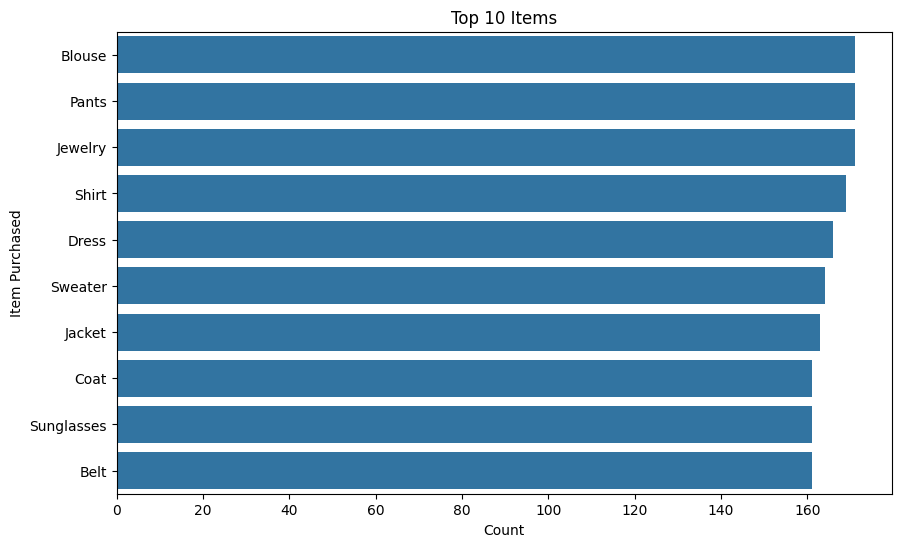

In [25]:
# TODO: plot a horizontal bar chart of the top 10 items with sns.barplot()
plt.figure(figsize=(10, 6))
sns.barplot(
    data = top10_items,
    x = 'Count', 
    y = 'Item Purchased',
    legend=False
)
plt.title('Top 10 Items')
plt.xlabel('Count')
plt.ylabel('Item Purchased')
plt.show()

In [31]:
top10_male_items = male_df['Item Purchased'].value_counts().reset_index()
top10_male_items.columns = ['Item Purchased', 'Count']
top10_male_items = top10_male_items.head(10)

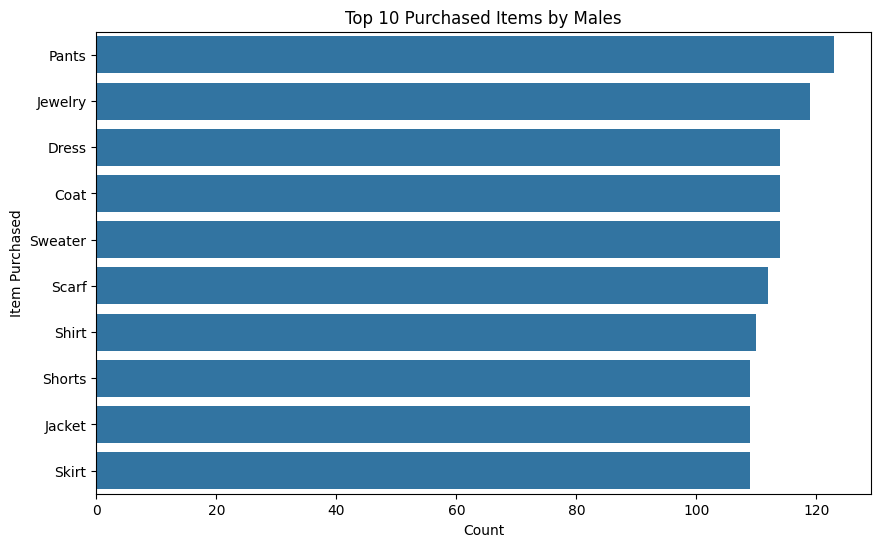

In [32]:
# TODO: plot a horizontal bar chart of the top 10 items for males with sns.barplot()
plt.figure(figsize=(10, 6))
sns.barplot(
    data = top10_male_items,
    x = 'Count', 
    y = 'Item Purchased',
    legend=False
)
plt.title("Top 10 Purchased Items by Males")
plt.xlabel('Count')
plt.ylabel('Item Purchased')
plt.show()

In [34]:
top10_female_items = female_df['Item Purchased'].value_counts().reset_index()
top10_female_items.columns = ['Item Purchased', 'Count']
top10_female_items = top10_female_items.head(10)

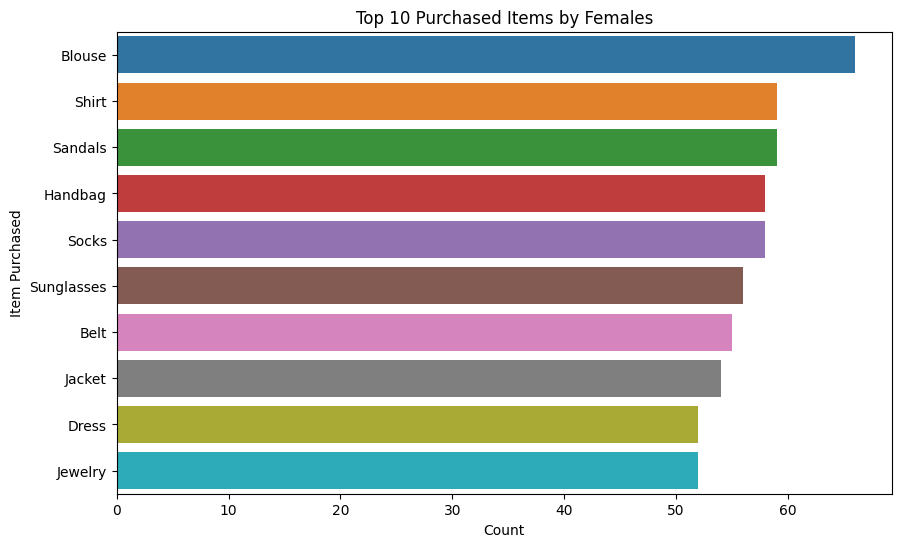

In [37]:
# TODO: plot a horizontal bar chart of the top 10 items for females with sns.barplot()
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top10_female_items,
    y='Item Purchased',
    x='Count',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items by Females")
plt.xlabel('Count')
plt.ylabel('Item Purchased')
plt.show()

In [39]:
# TODO: count Size with value_counts() for all customers
size_counts = df['Size'].value_counts().reset_index()
size_counts.columns = ['Size', 'Count'] 
print(size_counts)

  Size  Count
0    M   1755
1    L   1053
2    S    663
3   XL    429


In [41]:
# TODO: count Size with value_counts() for male_df and female_df
male_size_counts = male_df['Size'].value_counts().reset_index()
male_size_counts.columns = ['Size', 'Count']   

female_size_counts = female_df['Size'].value_counts().reset_index()
female_size_counts.columns = ['Size', 'Count']   

print(male_size_counts)
print(female_size_counts)

  Size  Count
0    M   1165
1    L    716
2    S    476
3   XL    295
  Size  Count
0    M    590
1    L    337
2    S    187
3   XL    134


### **Category**

In [42]:
# TODO: count Category with value_counts().reset_index() for all customers
ctg = df['Category'].value_counts().reset_index()
ctg.columns = ['Category', 'Count'] 
print(ctg)

      Category  Count
0     Clothing   1737
1  Accessories   1240
2     Footwear    599
3    Outerwear    324


In [ ]:
# TODO: count Category with value_counts().reset_index() for male_df and female_df
male_ctg = male_df['Category'].value_counts().reset_index()
male_ctg.columns = ['Category', 'Count']
female_ctg = female_df['Category'].value_counts().reset_index()
female_ctg.columns = ['Category', 'Count']
print(male_ctg)
print(female_ctg)

      Category  Count
0     Clothing   1181
1  Accessories    848
2     Footwear    400
3    Outerwear    223
      Category  Count
0     Clothing    556
1  Accessories    392
2     Footwear    199
3    Outerwear    101


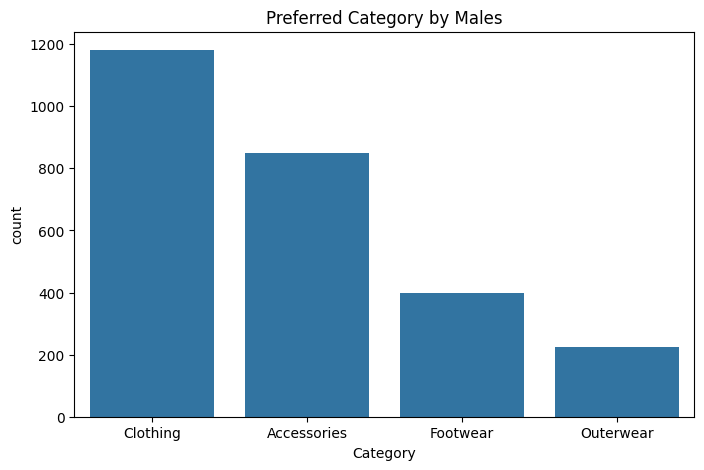

In [44]:
# TODO: plot a bar chart of preferred Category for males with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    x='Category',
    y='Count',
    data=male_ctg
)
plt.title("Preferred Category by Males")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

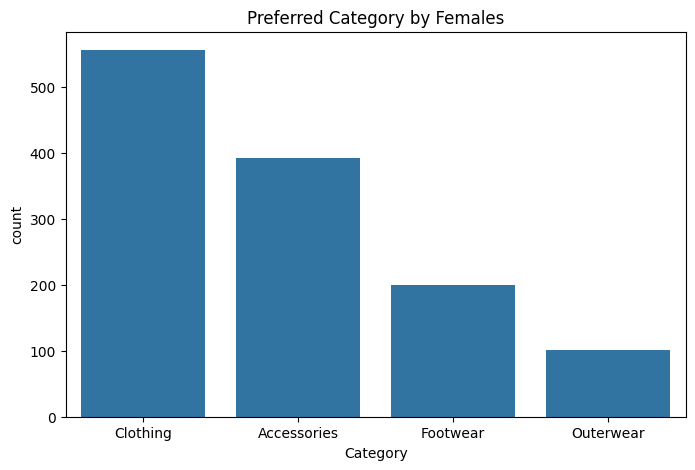

In [45]:
# TODO: plot a bar chart of preferred Category for females with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    x='Category',
    y='Count',
    data=female_ctg
)
plt.title("Preferred Category by Females")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

In [47]:
ctg = df.groupby(['Gender', 'Category']).size().reset_index(name='count')

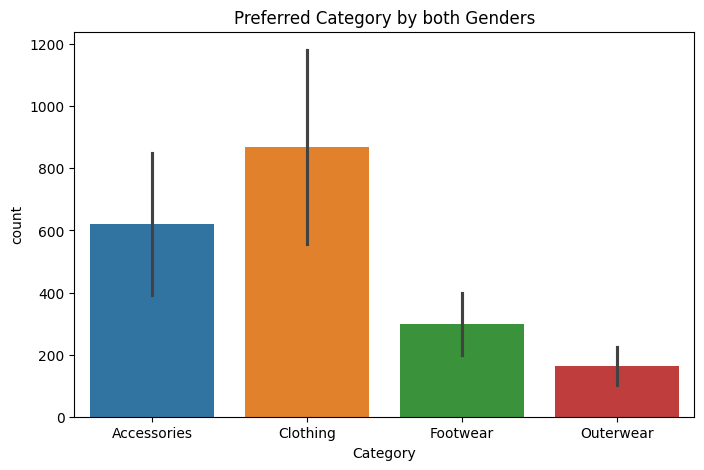

In [48]:
# TODO: plot a bar chart of preferred Category for both genders with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category by both Genders")
plt.show()


In [49]:
# TODO: create waffle_data_m and waffle_data_f from Category value_counts()
waffle_data_m = dict(male_df['Category'].value_counts())
waffle_data_f = dict(female_df['Category'].value_counts())


# TODO: create waffle_data_f from female_df['Category'].value_counts()
waffle_data_m = dict(male_df['Category'].value_counts())
waffle_data_f = dict(female_df['Category'].value_counts())


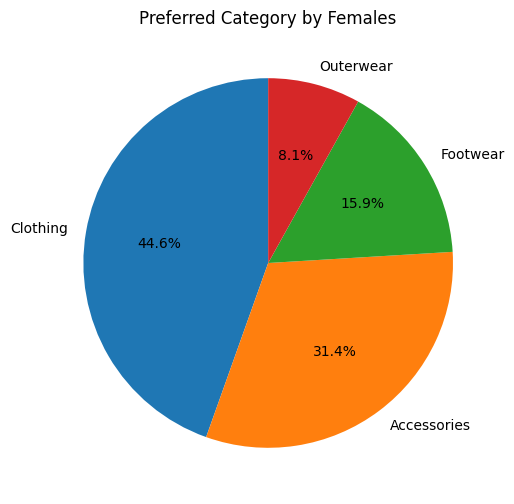

In [50]:
# TODO: plot a pie chart of preferred Category for females with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    waffle_data_f.values(),
    labels=waffle_data_f.keys(),
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Preferred Category by Females")
plt.show()

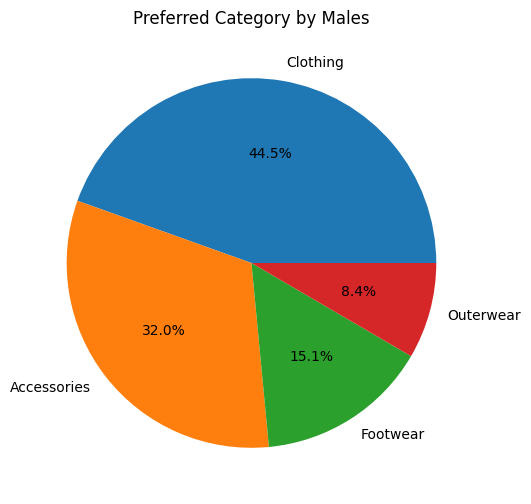

In [51]:
# TODO: plot a pie chart of preferred Category for males with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    waffle_data_m.values(),
    labels=waffle_data_m.keys(),
    autopct='%1.1f%%'
)
plt.title("Preferred Category by Males")
plt.show() 

### **Review ratings**

In [52]:
# TODO: filter female Clothing rows, then mean of Review Rating
cr_f = female_df[female_df['Category'] == 'Clothing']['Review Rating']
avg_cr_f = cr_f.mean()

In [53]:
# TODO: filter male Clothing rows, then mean of Review Rating
cr_m = male_df[male_df['Category'] == 'Clothing']['Review Rating']
avg_cr_m = cr_m.mean()

In [54]:
avg_cr_m,avg_cr_f 

(np.float64(3.7319220999153258), np.float64(3.7044964028776977))

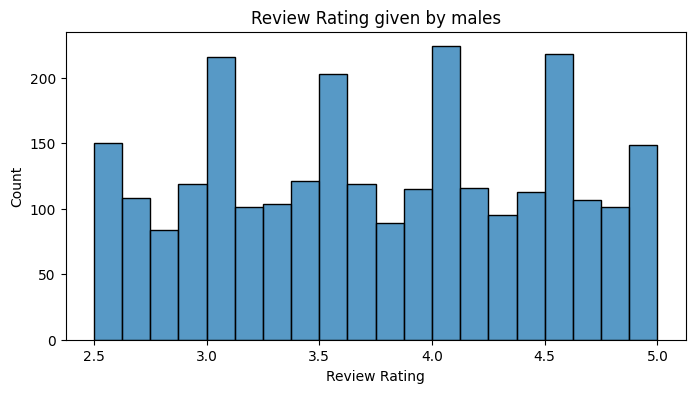

Text(0.5, 1.0, 'Review Rating given by females')

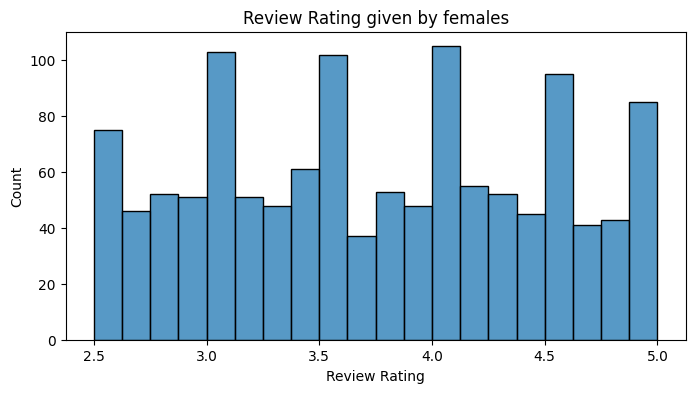

In [55]:
# TODO: plot Review Rating histograms for males and females with sns.histplot()
# males
plt.figure(figsize=(8, 4))
sns.histplot(data=male_df, x='Review Rating', bins=20)
plt.title("Review Rating given by males")
plt.show()

# females
plt.figure(figsize=(8, 4))
sns.histplot(data=female_df, x='Review Rating', bins=20)
plt.title("Review Rating given by females") 


In [57]:
# TODO: count Review Rating with value_counts() for male Clothing (cr_m)
cr_m_counts = cr_m.value_counts()
print(cr_m_counts)


Review Rating
3.7    61
3.4    59
2.7    55
2.9    55
4.2    52
3.9    52
4.0    52
3.0    49
3.3    49
4.1    48
4.9    48
3.5    48
3.6    46
4.8    46
4.7    46
3.1    46
4.6    46
4.3    45
2.6    45
4.4    43
3.2    41
2.8    41
3.8    39
4.5    36
2.5    17
5.0    16
Name: count, dtype: int64


### **Purchase Amount (USD)**

In [59]:
# TODO: sum Purchase Amount (USD) for males
m_tpa = male_df['Purchase Amount (USD)'].sum()  

# # TODO: sum Purchase Amount (USD) for females
f_tpa = female_df['Purchase Amount (USD)'].sum()

print(f"Total Purchase Amount for Males: ${m_tpa:.2f}")
print(f"Total Purchase Amount for Females: ${f_tpa:.2f}")   

Total Purchase Amount for Males: $157890.00
Total Purchase Amount for Females: $75191.00


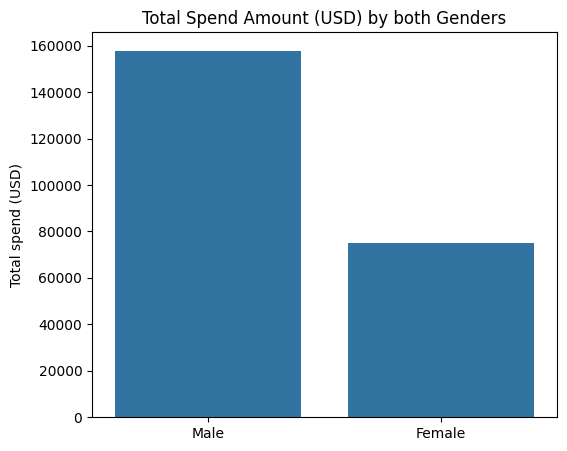

In [60]:
# TODO: plot total spend by gender with sns.barplot()
plt.figure(figsize=(6, 5))
sns.barplot(
    x=['Male', 'Female'],
    y=[m_tpa, f_tpa]
)
plt.title("Total Spend Amount (USD) by both Genders")
plt.ylabel('Total spend (USD)')
plt.show()

In [63]:
# TODO: filter female_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_f = cr_f
ca_f = female_df[female_df['Category']=='Accessories']
cf_f = female_df[female_df['Category']=='Footwear']
co_f = female_df[female_df['Category']=='Outerwear']

print(cc_f) 
print(ca_f)
print(cf_f)
print(co_f)

2652    3.3
2653    4.8
2656    3.6
2657    2.7
2660    4.9
       ... 
3889    3.5
3890    2.6
3891    4.7
3894    3.9
3895    4.2
Name: Review Rating, Length: 556, dtype: float64
      Age  Gender Item Purchased     Category  Purchase Amount (USD)  \
2655   26  Female     Sunglasses  Accessories                     83   
2658   52  Female        Handbag  Accessories                     47   
2664   22  Female        Jewelry  Accessories                     84   
2669   39  Female           Belt  Accessories                     28   
2670   30  Female     Sunglasses  Accessories                     44   
...   ...     ...            ...          ...                    ...   
3892   35  Female        Jewelry  Accessories                     86   
3893   21  Female            Hat  Accessories                     64   
3896   52  Female       Backpack  Accessories                     49   
3897   46  Female           Belt  Accessories                     33   
3899   52  Female        Ha

In [66]:
# TODO: filter male_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_m = cr_m
ca_m = male_df[male_df['Category']=='Accessories']
cf_m = male_df[male_df['Category']=='Footwear']
co_m = male_df[male_df['Category']=='Outerwear']
print(cc_m)
print(ca_m)
print(cf_m)
print(co_m) 

0       3.1
1       3.1
2       3.1
4       2.7
6       3.2
       ... 
2640    4.0
2644    3.3
2646    3.9
2648    3.9
2650    4.2
Name: Review Rating, Length: 1181, dtype: float64
      Age Gender Item Purchased     Category  Purchase Amount (USD)  \
9      57   Male        Handbag  Accessories                     31   
16     25   Male     Sunglasses  Accessories                     36   
26     38   Male        Jewelry  Accessories                     20   
28     54   Male        Handbag  Accessories                     94   
30     57   Male        Jewelry  Accessories                     31   
...   ...    ...            ...          ...                    ...   
2641   25   Male     Sunglasses  Accessories                     60   
2642   39   Male           Belt  Accessories                     87   
2643   49   Male         Gloves  Accessories                     41   
2645   23   Male          Scarf  Accessories                     81   
2649   23   Male         Gloves  Acce

In [68]:
# TODO: create pcu dict from Promo Code Used value_counts()
pcu = dict(df['Promo Code Used'].value_counts())
print(pcu)

{'No': np.int64(2223), 'Yes': np.int64(1677)}


### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

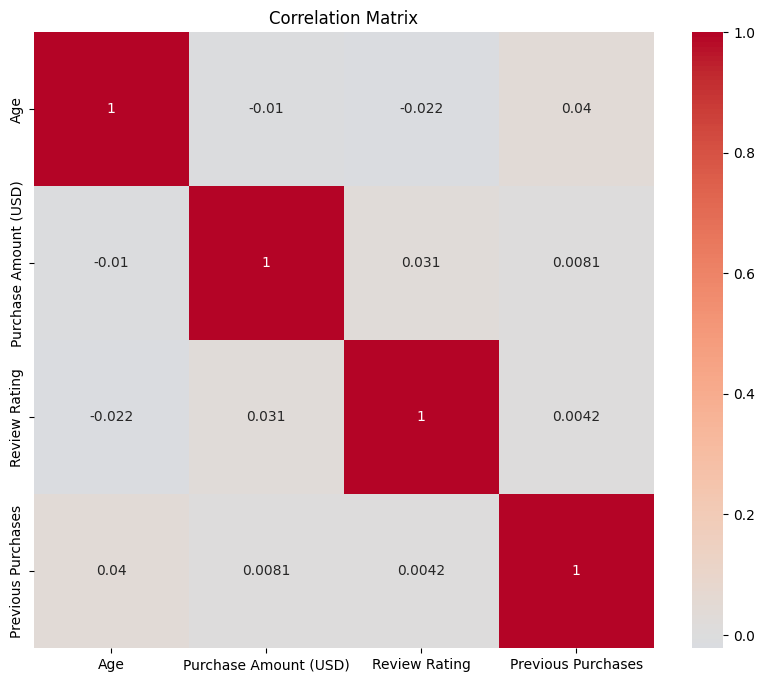

In [69]:
# TODO: compute correlation with df.corr(numeric_only=True), then plot a heatmap with sns.heatmap()
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()


### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

In [72]:
# TODO: dummy variables for Gender, Size, and Category with pd.get_dummies()
df = pd.get_dummies(df, columns=['Gender', 'Size', 'Category'], dtype=int)
df.head()


,Age,Item Purchased,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,...,Gender_Female,Gender_Male,Size_L,Size_M,Size_S,Size_XL,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear
0,55,Blouse,53,Kentucky,Gray,Winter,3.1,Yes,Credit Card,Express,...,0,1,1,0,0,0,0,1,0,0
1,19,Sweater,64,Maine,Maroon,Winter,3.1,Yes,Bank Transfer,Express,...,0,1,1,0,0,0,0,1,0,0
2,50,Jeans,73,Massachusetts,Maroon,Spring,3.1,Yes,Cash,Free Shipping,...,0,1,0,0,1,0,0,1,0,0
3,21,Sandals,90,Rhode Island,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,...,0,1,0,1,0,0,0,0,1,0
4,45,Blouse,49,Oregon,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,...,0,1,0,1,0,0,0,1,0,0


In [73]:
# TODO: use MinMaxScaler on Purchase Amount (USD) and StandardScaler on Age (keep original columns)
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df['Amount_minmax'] = MinMaxScaler().fit_transform(df[['Purchase Amount (USD)']])
df['Age_standard'] = StandardScaler().fit_transform(df[['Age']])
df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
# TODO: use pd.cut() to bin Purchase Amount (USD) into Low / Medium / High
# df['Amount_bin'] = ?
# df['Amount_bin'].value_counts()

### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
- Which items and categories are most common for males vs females?
- Do males and females spend a similar total amount?
- Is Review Rating similar across genders?
- How often is a promo code used?

# TODO: write insights
- 
- 
- 
- 

Caveat: correlation is not causation.